## Apresentação ✒️

Notebook destinado à implementação dos modelos de Decision Tree e Regressão Logística, dois modelos de aprendizado supervisionado voltados para classificação. O primeiro pode ser compreendido segundo uma estrutura de árvore, de modo que proceduralmente dois nodes são gerados a partir da quebra binária em relação ao node anterior, na forma em que busca-se compreender quais conjuntos de dados se referem a uma determinada classe a partir da maior homogeneidade presente em cada node. 

O segundo, é construído mediante à combinação do modelo de regressão linear e da função logística - sigmoide - que permite ao modelo ajustar às features do dataset e produzir um resultado sujeito a um intervalo entre 0 e 1, o qual pode ser compreendido como a probabilidade de uma predição se referir a uma classe ou outra. Ambos os modelos tem como base a realização de classificação de forma binária, ainda que podem comportar classificações multinomias. 

Isto posto, no presente notebook existirá a implementação de ambos os modelos junto da mensuração da sua qualidade de ajuste por meio de uma validação cruzada. Ao mesmo tempo, os modelos serão instanciados com vias de permitir a introdução de hiperparâmetros que sirvam para melhorar a capacidade de ajuste de cada qual aos dados, acentuando a sua qualidade de resposta. 

Por fim, importante salientar que no contexto de classificação as métricas utilizadas para mensurar a qualidade de ajuste do modelo podem ser :

- Acurácia (serve apenas como uma compreensão global, devendo ser apenas utilizada para datasets que apresentam classes equilibradas entre si, isto é, com mesmo percentual em relação ao universo total das classes existentes)

- Precision 

- Recall

- F1-score

- ROC-AUC

- Matriz de confusão

- Cross-entropy (comum para MLP)

- Gini e entropia (para divisão dos nodes da árvore de decisão)

Como o foco desse notebook não se circunscreve no estudo acerca de cada métrica, estarei deixando um link para o artigo que se debruça sobre elas, o qual compreende também as métricas que são utilizadas em contexto de regressão : [Métricas de avaliação para Machine Learning](https://medium.com/@brunoloducca15/métricas-de-avaliação-para-machine-learning-249f16d104da)


### Library 📚

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [14]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from pandas import DataFrame

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
        
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris

### Carregando o dataset 💾

In [15]:
iris = load_iris()

data = iris.data
columns = iris.feature_names

df = DataFrame(
    data    = data, 
    columns = columns
)

df["target"] = iris.target

In [16]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
df.shape

(150, 5)

### Analisando a integridade do dataset 🔎

In [8]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.target.value_counts()

target
0    50
1    50
2    49
Name: count, dtype: int64

### Exploração dos dados 🕸️

Verificando a presença de outliers, distribuição dos dados e o nível de correlação entre as features

In [17]:
# Verificando a presença de outliers nos dados por meio do recurso
# conhecido como boxplot, um gráfico que compreende a distribuição 
# dos dados, segundo um percentual conhecido como quartis. 

def boxplot(
          dataset: DataFrame, 
          style : str, 
          height : int, 
          width : int
      ):
      
      """ 
      Generates a series of boxplots for each feature in the provided dataset.

      This function uses Seaborn and Matplotlib to create boxplots for all columns in the dataset. 
      The visual style of the plots is set using the provided style parameter. The plots are arranged 
      in a grid layout with 2 rows and 3 columns, and the figure size is determined by the height and 
      width parameters.

      Args:
        dataset (DataFrame): The dataset containing the features to be visualized.
        style (str): The Seaborn style theme to be applied to the plots (e.g., "darkgrid", "whitegrid").
        height (int): The height of the overall figure.
        width (int): The width of the overall figure.

      Returns:
        None: This function displays the boxplots directly using Matplotlib's `plt.show()`.
      """

      sns.set_theme(style=style)
      
      feature = dataset.columns
      plt.figure(figsize=(height, width))

      for i, feature in enumerate(feature, 1):
          plt.subplot(2, 3, i)
          sns.boxplot(data=df[feature])
          plt.title(f"Boxplot de {feature}")
      
      plt.tight_layout()
      plt.show()

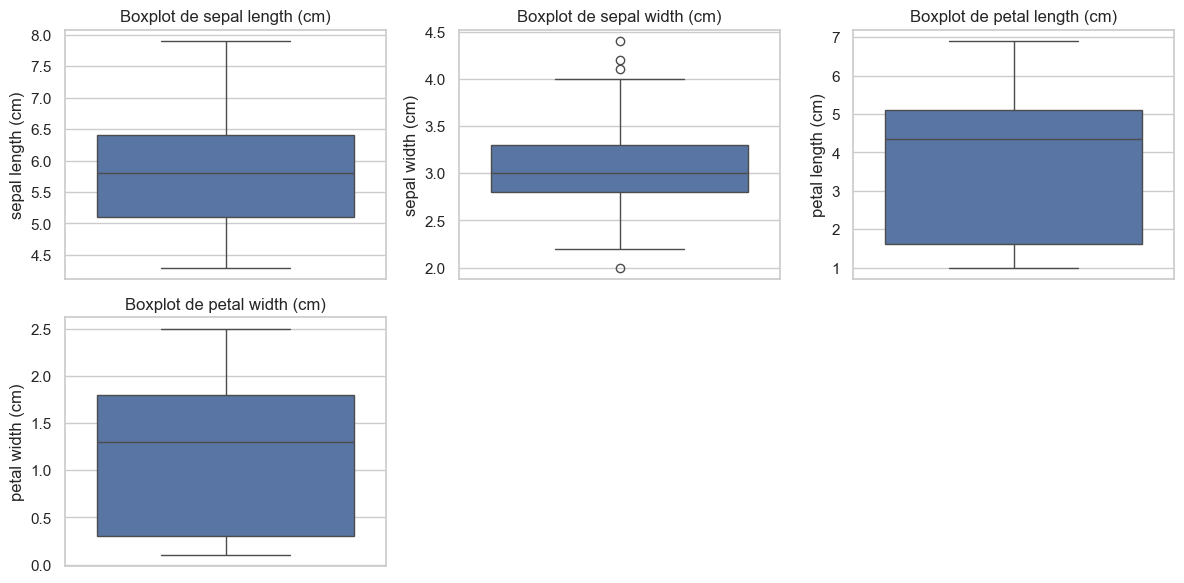

In [24]:
boxplot(
    dataset = df.drop("target", axis=1), 
    style   = "whitegrid", 
    height  = 12, 
    width   = 6
)


Ao analisar o gráfico, nota-se que boa parte das features não apresentam outliers, com exceção de uma, que apresenta alguns outliers que excedem o limite superior e inferior encontrados. Nesse sentido, pode ser necessário aplicar alguma transformação ou normalização para tornar a distribuição mais simétrica e, assim, tolher os outliers verificados. Como o objetivo principal do notebook é realizar apenas um *mise en place* para os modelos citados, não irei desenvolver essa etapa, contentado-se apenas em normalizar os dados para que sejam, então, passados para os modelos. 

In [25]:
# Verificando a distribuição dos dados

def data_distribuition(
        dataset: DataFrame, 
        style : str, 
        height: int, 
        width: int, 
        bins: int
        ):
    """ 
    Visualizes the distribution of each feature in the dataset using histograms.

    Parameters:
    ----------
    dataset : DataFrame
        The dataset to be visualized, where each column represents a feature.
    
    style : str
        Seaborn theme for plot styling (e.g., 'darkgrid', 'whitegrid').
    
    height : int
        The height of the figure in inches.
    
    width : int
        The width of the figure in inches.
    
    bins : int
        Number of bins for the histograms.
    """
    feature = dataset.columns
    sns.set_theme(style=style)

    # Determinar o número de linhas no grid :
    
    # Fixo para 3 colunas
    n_cols = 3 

    # Calcular o número de linhas necessárias
    n_rows = (len(feature) + n_cols - 1) // n_cols  

    plt.figure(figsize=(height, width))

    for i, feature in enumerate(feature, 1):

        data = dataset[feature]

        plt.subplot(n_rows, n_cols, i)
        sns.histplot(data, kde=True, bins=bins)
        plt.title(f"Histograma de {feature}")


    plt.tight_layout()
    plt.show()

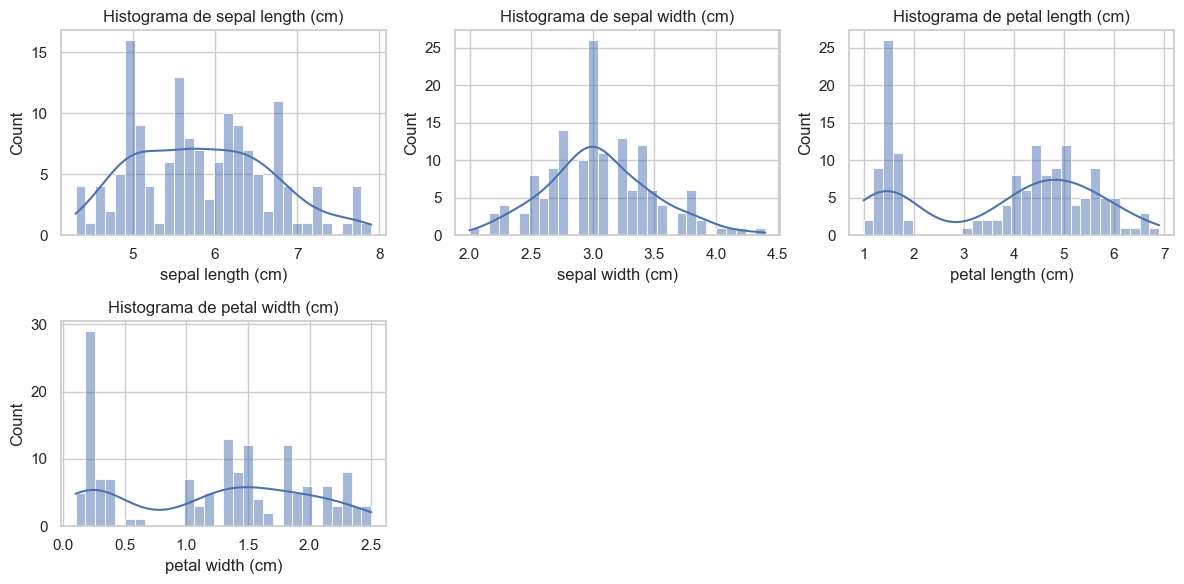

In [28]:
data_distribuition(
    dataset = df.drop("target", axis=1),
    style   = "whitegrid", 
    height  = 12, 
    width   = 6, 
    bins    = 30
)

In [29]:
# Matriz de correlação 

def pearson_matrix(
        dataset: DataFrame, 
        color: str, 
        height: int, 
        width: int
    ):
    """ 
    Generates a heatmap to visualize the Pearson correlation matrix of a dataset.

    Parameters:
    ----------
    dataset : DataFrame
        The dataset whose features' correlations will be computed and visualized.
    
    color : str
        The colormap for the heatmap (e.g., 'coolwarm', 'viridis').
    
    height : int
        The height of the heatmap figure in inches.
    
    width : int
        The width of the heatmap figure in inches.
    """
    corr_matrix = dataset.corr()

    plt.figure(figsize=(height, width))
    sns.heatmap(corr_matrix, annot=True, cmap=color, fmt=".2f")

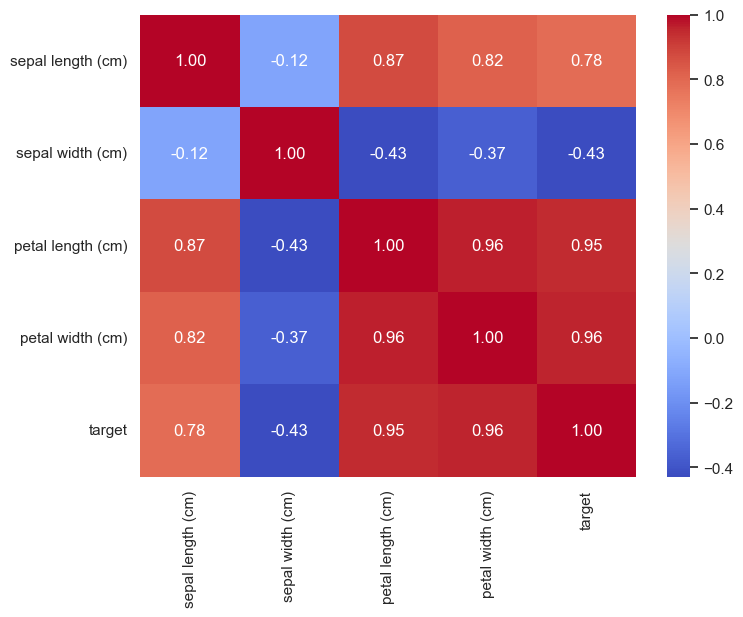

In [32]:
pearson_matrix(
    dataset = df, 
    color   = "coolwarm", 
    height  = 8, 
    width   = 6
)

A utilização do modelo de regressão logística assume que as features apresentam uma relação linear com a variável target (comumente nomeada como label em contexto de classificação), uma vez que de outro modo, o modelo apresenta pouca capacidade de ajuste, produzindo baixa qualidade de resposta. Esse tipo de distribuição pode ser verificada de duas formas : por meio de uma disposição gráfica ou segundo a matriz de Pearson que se verifica acima. 

Considerando o nível de correlação entre a target e as respectivas features verificado, pode-se compreender que existe uma relação linear entre elas, de modo que sepal width concebe uma relação negativa enquanto as demais outras positiva. Caso não existisse relação linear, sendo essa complexa, a matriz denotaria isso por meio dos níveis percentuais próximos - se não igual - a zero.  

### Normalização 

A normalização é o recurso utilizado para deixar as features numa mesma escala, contribuindo com a precisão do modelo, pois dessa forma tende a diminuir os ruídos existentes, bem como mitigiar a influência - com ressalvas - de outliers. A normalização é fortemente indicada para modelos que são baseados em distância, como regressão logística, SVM's K-NN etc, sendo menos relevante - comparativamente - aos modelos baseados em árvores. Dessa forma, nesse notebook será ajustado ambos os modelos citados, tanto com os dados normalizados quanto com esses não normalizados, com vias de verificar o impacto na qualidade ajuste. 

In [ ]:
"""
Ponto de atenção : estou realizando a normalização antes da separação dos dados 
nos seus segmentos de treino e teste, isso é errado, pois pode propriciar data
linkage, fenômeno no qual a informação dos dados de teste podem vazar para treino, 
produzindo uma memorização da informação para o modelo e não seu aprendizado de fato. 

Nesse sentido, faz-se necessário que, até mesmo na normalização, realize a segmentação
primeiro antes. Só não estou fazendo no presente notebook, pois ele está sendo pensado
para fazer um mise en place para os modelos citados. 
"""

X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

df_scaled = pd.concat([X_scaled_df, df["target"]], axis=1)
df_scaled.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,-0.900681,1.019004,-1.340227,-1.315444,0
1,-1.143017,-0.131979,-1.340227,-1.315444,0
2,-1.385353,0.328414,-1.397064,-1.315444,0
3,-1.506521,0.098217,-1.283389,-1.315444,0
4,-1.021849,1.249201,-1.340227,-1.315444,0


### SEED 


In [42]:
SEED = 115

### Decision Tree Classify 🌳

In [43]:
# Instanciando decision tree :

decision_tree = DecisionTreeClassifier(
    criterion        = "gini", 
    splitter         = "best", 
    max_depth        = 10, 
    min_samples_leaf = 5, 
    random_state     = SEED
)

### Regressão logística 📏

In [44]:
# Instanciando o modelo de regressão logística :

log_regression = LogisticRegression(
    penalty        = "elasticnet",
    tol            = 0.001, 
    random_state   = SEED,
    solver         = "saga", 
    l1_ratio       = 0.5,
    max_iter       = 100
)

### Validação cruzada (com os dados normalizados) 🔬

In [56]:
%%time

dt_nornie_metric = cross_val_score(decision_tree, X_scaled, y, cv=5, scoring="f1_weighted")
lg_nornie_metric = cross_val_score(log_regression, X_scaled, y, cv=5, scoring="f1_weighted")

CPU times: total: 0 ns
Wall time: 58.1 ms


In [57]:
print(f"Validação cruzada - Decision Tree: {dt_nornie_metric.round(2)} \nValidação cruzada - Logistic Regression: {lg_nornie_metric.round(2)}")

Validação cruzada - Decision Tree: [0.97 1.   0.9  0.87 1.  ] 
Validação cruzada - Logistic Regression: [0.97 1.   0.93 0.9  1.  ]


In [58]:
dt_mean   = np.mean(dt_nornie_metric).round(2)
dt_median = np.median(dt_nornie_metric).round(2)
dt_std    = np.std(dt_nornie_metric).round(2)

lg_mean   = np.mean(lg_nornie_metric).round(2)
lg_median = np.median(lg_nornie_metric).round(2)
lg_std    = np.std(lg_nornie_metric).round(2)

print(f"Nível do ajuste de Decision Tree - média: {dt_mean}, mediana: {dt_median}, desv. padrão {dt_std}")
print(f"Nível do ajuste da Regressão Logística - média: {lg_mean}, mediana: {lg_median}, desv. padrão {lg_std}")


Nível do ajuste de Decision Tree - média: 0.95, mediana: 0.97, desv. padrão 0.05
Nível do ajuste da Regressão Logística - média: 0.96, mediana: 0.97, desv. padrão 0.04


### Validação cruzada (com os dados não normalizados) 🔬

In [59]:
%%time

dt_metric = cross_val_score(decision_tree, X, y, cv=5, scoring="f1_weighted")
lg_metric = cross_val_score(log_regression, X, y, cv=5, scoring="f1_weighted")

CPU times: total: 15.6 ms
Wall time: 94.5 ms


In [60]:
print(f"Validação cruzada - Decision Tree: {dt_metric.round(2)} \nValidação cruzada - Logistic Regression: {lg_metric.round(2)}")

Validação cruzada - Decision Tree: [0.97 1.   0.86 0.87 1.  ] 
Validação cruzada - Logistic Regression: [1.   1.   0.97 0.97 1.  ]


In [61]:
dt_mean   = np.mean(dt_metric).round(2)
dt_median = np.median(dt_metric).round(2)
dt_std    = np.std(dt_metric).round(2)

lg_mean   = np.mean(lg_metric).round(2)
lg_median = np.median(lg_metric).round(2)
lg_std    = np.std(lg_metric).round(2)

print(f"Nível do ajuste de Decision Tree - média: {dt_mean}, mediana: {dt_median}, desv. padrão {dt_std}")
print(f"Nível do ajuste da Regressão Logística - média: {lg_mean}, mediana: {lg_median}, desv. padrão {lg_std}")


Nível do ajuste de Decision Tree - média: 0.94, mediana: 0.97, desv. padrão 0.06
Nível do ajuste da Regressão Logística - média: 0.99, mediana: 1.0, desv. padrão 0.02
